In [1]:
import numpy as np
print("Numpy:", np.__version__)

Numpy: 2.5.2


In [2]:
# Loading IMG Data

# Load training Images
X_train = np.load("../Model/X_train.npy")

# Load training Labels
y_train = np.load("../Model/y_train.npy")

# Confirm training data is loaded
print("Training Data Loaded Successfully!")

Training Data Loaded Successfully!


In [3]:
# check the shape of training images
print("X_train Shape:", X_train.shape)

# check the shape of training labels
print("y_train Shape:", y_train.shape)

X_train Shape: (31367, 32, 32, 3)
y_train Shape: (31367,)


In [4]:
# Loading Validation Dta

# Load Validation IMG
X_val = np.load("../Model/X_val.npy")

# Load Validation Labels
y_val = np.load("../Model/y_val.npy")

#Confirm Validation Data Is Loaded
print("Validation Data Loaded Successfully!")

Validation Data Loaded Successfully!


In [5]:
# Check Shape Of Validation IMG
print("X_val Shape:", X_val.shape)

# Check Shape of Validation Labels
print("y_val Shape:", y_val.shape)

X_val Shape: (7842, 32, 32, 3)
y_val Shape: (7842,)


In [6]:
# Checking The Data Types OF IMG And Lab

# Check Data Types Of Training IMG
print("X_train Data Type:", X_train.dtype)

# Check Data Types of Training Labels
print("Y_train Data Type:", y_train.dtype)

# Check Data Type Of Validation IMG
print("X_Val Data Type:", X_val.dtype)

# Check Data Type of Validation Labels
print("Y_val Data Type:", y_val.dtype)

X_train Data Type: float64
Y_train Data Type: int64
X_Val Data Type: float64
Y_val Data Type: int64


In [7]:
# Checking the pixel of img

# check Minimun Pixel Value of Training images
print("X_train Minimum:",X_train.min())

# check Maximum Pixel Value of Training images
print("X_train Maximum:",X_train.max())

# check Minimum Pixel Value of Validation images
print("X_Val Minimum:",X_val.min())

# Check Maximum Pixel Value Of Validation images
print("X_Val Maximum:",X_val.max())

X_train Minimum: 0.0
X_train Maximum: 1.0
X_Val Minimum: 0.0
X_Val Maximum: 1.0


In [8]:
# Checking Number Of Classes

# Find Unique Classes In training labels
classes = np.unique(y_train)

# Display the availabel classes
print("Classes:", classes)

# Display total number of classes Length
print("Total Classes:", len(classes))

Classes: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42]
Total Classes: 43


In [9]:
# import Tensorflow / Keras

import tensorflow as tf

# Import Keras For Building The Cnn
from tensorflow import keras

# Confirm Tensorflow is ready
print("TensorFlow:", tf.__version__)

TensorFlow: 2.21.0


In [10]:
# Import the Sequential model # Used to create cnn model layer by layer 1-2-3 etc.
from tensorflow.keras.models import Sequential  

# Import Convolution layer  # Its's Main Layer it detects edge,shape,Arrows,No,Sym.
from tensorflow.keras.layers import Conv2D 

# Import Pooling Layer  # Reducing The Size of unnecessary information
from tensorflow.keras.layers import MaxPooling2D

# Import Flatten Layer # Convert cnn 2d,2d features map into single 1D list Number goes in Dens Layer
from tensorflow.keras.layers import Flatten

# Import Fully Connected Layer # Dense Are Fully Connected Neural-Network Layer
from tensorflow.keras.layers import Dense

# Confirm CNN Layer Are Ready
print("CNN Layer Importtws Successgully")

CNN Layer Importtws Successgully


In [11]:
# Import Input Layer
from tensorflow.keras.layers import Input

# Create CNN Model
model = Sequential()

# Define input image shape
model.add(Input(shape=(32,32,3)))

# Confirm Model Is created
print("CNN Model Created Successfully")

CNN Model Created Successfully


In [12]:
# Add First Convolution Layer Conv2D

#Detects Basic features such as edges, shapes and patterns
model.add(Conv2D(32, (3,3), activation = 'relu'))

# Confirm first convolution layer is added
print("First Conv2D Layer Added")

First Conv2D Layer Added


In [13]:
# Add First MaxPooling Layer

# Reduces Feature Map Size While Keeping Important Features
model.add(MaxPooling2D(pool_size=(2,2)))

# Confirm Pooling Layer Is Added
print("First MaxPooling Layer Added")

First MaxPooling Layer Added


In [14]:
# Add Second Convolution Layer

# Learns More Complex Features From The Previous layer
model.add(Conv2D(64,(3,3), activation='relu'))

# Confirm Second Convolution Layer Is Added
print("Second Conv2D Layer Added")

Second Conv2D Layer Added


In [15]:
# Add Second MaxPooling Layer

# Reduces Feature map size while keeping important features
model.add(MaxPooling2D(pool_size=(2,2)))

# Confirm Second Pooling Layer Is Added
print("Second MaxPooling Layer Added")

Second MaxPooling Layer Added


In [16]:
# Add Flatten Layer

# Convert Feature Maps Into A Single 1D List
model.add(Flatten())

# Confirm Flatten Layer Is Added
print("Flatten Layer Added")

Flatten Layer Added


In [17]:
# Adding Fully Connected Dense Layer  (Dense Is Neural-Network Layer)
  
# Learn From Extracted Features For Classification
model.add(Dense(128, activation='relu'))  # 128 Neurons -> Small Decison Making

# Confirm Dense Layer Is Added
print("Dense Layer Added")

Dense Layer Added


In [18]:
# Add Final OutPut Layer

# Produces Probability for each of the 43 traffic-sign classes
model.add(Dense(43, activation='softmax'))  # Softmax -> onvery OP in Probabilities 0.11 , 0.99 etc

# Confirm Output Layer Is Added
print("Output Layer Added Successfully")

Output Layer Added Successfully


In [19]:
# Compile The Cnn Model

#Define how the model will learn and measure mistake
model.compile(
    optimizer = 'adam', #How the model update  itself
    loss = 'sparse_categorical_crossentropy',  #Hohw Model Mistek The Mesaure when prediction
    metrics = ['accuracy']  # How we measure correct prediction
)

# Cinfirm model is compiled
print("CNN Model Compiled Successfully")

CNN Model Compiled Successfully


In [20]:
# Startin To Train The CNN Modek

# Model learns traffic-sign patterns from training images
# history use to store 10 epochs result 
history = model.fit(
    X_train,
    y_train,
    epochs = 10,
    validation_data = (X_val,y_val)
)

# Confirm training is complete
print("CNN Model Training Completed")

Epoch 1/10
981/981 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - accuracy: 0.7065 - loss: 1.0693 - val_accuracy: 0.9306 - val_loss: 0.2636
Epoch 2/10
981/981 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.9556 - loss: 0.1670 - val_accuracy: 0.9486 - val_loss: 0.1809
Epoch 3/10
981/981 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.9776 - loss: 0.0875 - val_accuracy: 0.9793 - val_loss: 0.0849
Epoch 4/10
981/981 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.9851 - loss: 0.0548 - val_accuracy: 0.9834 - val_loss: 0.0783
Epoch 5/10
981/981 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.9901 - loss: 0.0373 - val_accuracy: 0.9805 - val_loss: 0.0871
Epoch 6/10
981/981 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.9925 - loss: 0.0289 - val_accuracy: 0.9857 - val_loss: 0.0714
Epoch 7/10
981/981 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.9929 - loss: 0.0269 - val_accuracy: 0.9898 - val_loss: 0.0519
Epoch 8/10
981/981 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.9949 - loss: 0.0177 - val_acc

In [21]:
# Import Matplotlib for creating graphs
import matplotlib.pyplot as plt

# Confirm Matplotlib Is Ready
print("Matplotlib Ready")

Matplotlib Ready


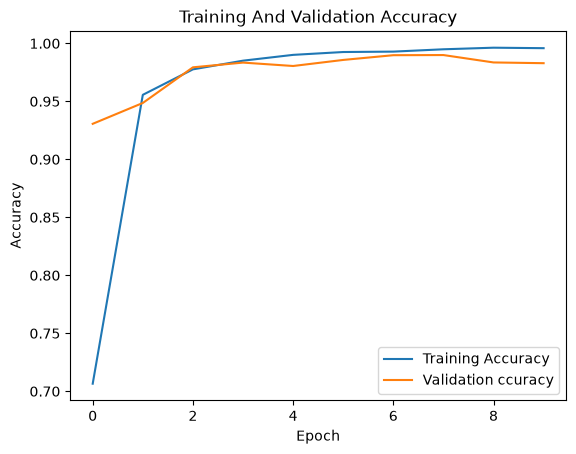

In [22]:
# Accuracy Graph

# Get Training Accuracy
train_accuracy = history.history['accuracy']  # Its Get the training accuracy of all epochs

# Get Validation Accuracy
val_accuracy = history.history['val_accuracy'] # this get validation accuracy after every epoch

# Create Accuracy Graph
plt.plot(train_accuracy, label='Training Accuracy')  #(plt.plot use to plot line  -  label one 
plt.plot(val_accuracy, label='Validation ccuracy')  # Show how accuracy change during training

# Add Graph Details
plt.title('Training And Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Display Graph
plt.show()

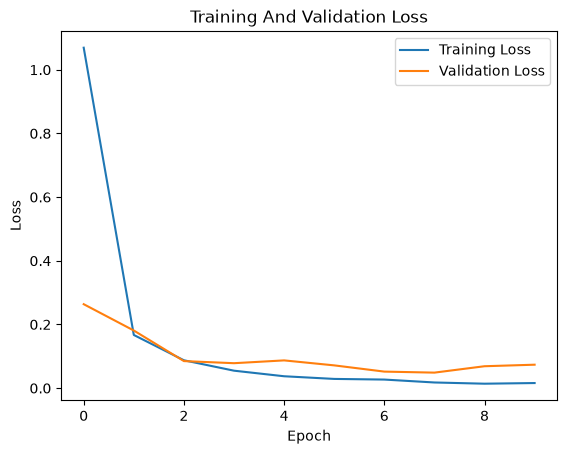

In [23]:
# Training And Validation Loss Graph

# Get Training Loss
train_loss = history.history['loss']

# Get Validationo Loss
val_loss = history.history['val_loss']

# Create Lloss Graph
plt.plot(train_loss, label = 'Training Loss')
plt.plot(val_loss, label = 'Validation Loss')

# Add Graph Details

plt.title('Training And Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Display Graph
plt.show()

In [24]:
# Evaluate The CNN

# Evaluate CNN Mmodel On Validation Data
val_loss, val_accuracy = model.evaluate(X_val, y_val) # Test Model Using X_val ad y_val

# Display Evaluation Result
print("Validation Loss:", val_loss) # Merasures Model Prediction Error
print("Validation Accuracy:", val_accuracy) # Measures how Many Validation Img Classified Correctly

246/246 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9829 - loss: 0.0736
Validation Loss: 0.07357928156852722
Validation Accuracy: 0.982912540435791


In [25]:
# Select One img from validation data
test_image = X_val[0]

# Get the actual class of the img
actual_class = y_val[0]

# Display The Acutual Class
print("Actual Class:", actual_class)

Actual Class: 28


In [26]:
# Make prediction using CNN
prediction = model.predict(np.expand_dims(test_image, axis=0))

# Get the class with highest probability
predicted_class = np.argmax(prediction)

# Display the predicted class
print("Predicted Class:", predicted_class)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
Predicted Class: 28


In [27]:
# Get the highest prediction probability
confidence = np.max(prediction)

# Convert pribability into percentage
confidence = confidence * 100

# Display Prediction Confidence
print("Prediction Confidence:", confidence, "%")

Prediction Confidence: 99.17101 %


In [28]:
# Test Multiple Validatio Images
for i in range(5):
    test_image = X_val[i]
    actual_class = y_val[i]

    prediction = model.predict(
        np.expand_dims(test_image, axis=0),
        verbose=0
    )

    predicted_class = np.argmax(prediction)
    confidence = np.max(prediction) * 100

    print(
    "Image:", i,
    "| Actual:", actual_class,
    "| Predicted:", predicted_class,
    "| Confidence:", round(confidence, 2), "%"
    )

Image: 0 | Actual: 28 | Predicted: 28 | Confidence: 99.17 %
Image: 1 | Actual: 2 | Predicted: 2 | Confidence: 99.99 %
Image: 2 | Actual: 1 | Predicted: 1 | Confidence: 100.0 %
Image: 3 | Actual: 25 | Predicted: 25 | Confidence: 100.0 %
Image: 4 | Actual: 38 | Predicted: 38 | Confidence: 100.0 %


In [29]:
# Confusion Matrix

# Predict Classes for all validation images
y_pred = model.predict(X_val, verbose = 1)

# Convert probabilities into predicted class numbers
y_pred_classes = np.argmax(y_pred, axis = 1)

# Confirm Prediction are generated
print("Validation Prediction Genrated Successfully")

246/246 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
Validation Prediction Genrated Successfully


In [30]:
# Importing Confusion Matrix
from sklearn.metrics import confusion_matrix

print("Confusion Matrix Ready")

Confusion Matrix Ready


In [31]:
# Calculating Confusion_Matrix
cm = confusion_matrix(y_val, y_pred_classes)

# Display the confusion matrix shape
print("Confusion Matrix Shape:", cm.shape)

Confusion Matrix Shape: (43, 43)


In [32]:
# Displaying Confusion Matrix
print(cm)

[[ 42   0   0 ...   0   0   0]
 [  8 433   0 ...   0   0   0]
 [  3   3 438 ...   0   0   0]
 ...
 [  0   0   0 ...  72   0   0]
 [  0   0   0 ...   0  48   0]
 [  0   0   0 ...   0   0  48]]


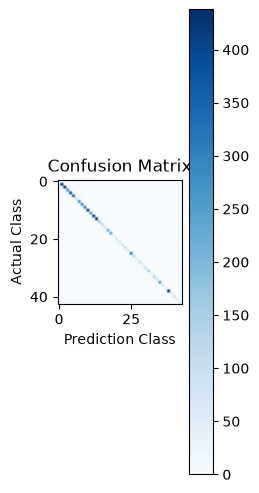

In [33]:
# Visual Confusion Matrix

# Displaying CM as a graph
plt.figure(figsize = (2,10))

plt.imshow(cm, cmap='Blues')

# Add color bar
plt.colorbar()

# Add graph title
plt.title("Confusion Matrix")

# dd axis labels
plt.xlabel("Prediction Class")
plt.ylabel("Actual Class")

# Display Graph
plt.show()

In [34]:
# Import classification report
from sklearn.metrics import classification_report

# Generate classification report
report = classification_report(y_val, y_pred_classes)

# Display classification report
print(report)

              precision    recall  f1-score   support

           0       0.65      1.00      0.79        42
           1       0.98      0.98      0.98       444
           2       1.00      0.97      0.99       450
           3       0.89      1.00      0.94       282
           4       0.99      0.96      0.98       396
           5       1.00      0.92      0.96       372
           6       1.00      1.00      1.00        84
           7       0.99      0.98      0.99       288
           8       0.97      0.99      0.98       282
           9       0.99      1.00      0.99       294
          10       1.00      1.00      1.00       402
          11       1.00      0.97      0.98       264
          12       1.00      1.00      1.00       420
          13       1.00      1.00      1.00       432
          14       1.00      0.99      0.99       156
          15       0.98      1.00      0.99       126
          16       1.00      1.00      1.00        84
          17       0.99    

In [35]:
# Import OS for working with folders and file paths
import os

# Confirm OS is ready
print("OS Library Ready")

OS Library Ready


In [36]:
# GTSRB Test DataSet-Step-1

# Set the path of official test img
test_path = "../DataSet/Test"

# Check wheather the test folder exists
print("Test Path:", test_path)
print("Test Folder Exists:", os.path.exists(test_path))

Test Path: ../DataSet/Test
Test Folder Exists: True


In [37]:
# GTSRB Test DataSet-Step-2

test_files = os.listdir(test_path)

# Display the first 10 test files
print("First 10 Test Files:")
print(test_files[:10])

# Display total number of test files
print("Total Test Files:", len(test_files))

First 10 Test Files:
['00000.png', '00001.png', '00002.png', '00003.png', '00004.png', '00005.png', '00006.png', '00007.png', '00008.png', '00009.png']
Total Test Files: 12631


In [38]:
# Check all file types in the test folder
for file_name in test_files:
    if not file_name.endswith(".png"):
        print("Non-PNG File:", file_name)

Non-PNG File: GT-final_test.csv


In [39]:
# Import pandas for reading the csv file
import pandas as pd

# Load the offical test labels
test_csv = pd.read_csv("../DataSet/GT-final_test.csv", sep = ";")

# Display the first 5 rows
print(test_csv.head())

# Display the column names
print("Columns:", test_csv.columns.tolist())

    Filename  Width  Height  Roi.X1  Roi.Y1  Roi.X2  Roi.Y2  ClassId
0  00000.ppm     53      54       6       5      48      49       16
1  00001.ppm     42      45       5       5      36      40        1
2  00002.ppm     48      52       6       6      43      47       38
3  00003.ppm     27      29       5       5      22      24       33
4  00004.ppm     60      57       5       5      55      52       11
Columns: ['Filename', 'Width', 'Height', 'Roi.X1', 'Roi.Y1', 'Roi.X2', 'Roi.Y2', 'ClassId']


In [40]:
# Import OpenCV for reading test images
import cv2

# Confirm OpenCV is ready
print("OpenCV:", cv2.__version__)

OpenCV: 5.0.0


In [41]:
# Get the first test img path
first_test_image_path = os.path.join(test_path, "00000.png")

# Read the test img
first_test_image = cv2.imread(first_test_image_path)

# Display the shape
print("First Test Image Shape:", first_test_image.shape)

# Display its data type
print("First Test Image Dta Type:", first_test_image.dtype)

First Test Image Shape: (54, 53, 3)
First Test Image Dta Type: uint8


In [42]:
# Create empty list for test images
X_test = []

# Create empty list for test labels
y_test = []

# Confirm test data lists are ready
print("Test Data Lists Created Successfully")

Test Data Lists Created Successfully


In [43]:
# Load all official test images and labels
for i in range(len(test_csv)):
    # Get the image filename from the CSV
    image_name = test_csv.iloc[i]["Filename"]

    # Convert .ppm filename to .png filename
    image_name = image_name.replace(".ppm", ".png")

    # Create the complete image path
    image_path = os.path.join(test_path, image_name)

    # Read the test image
    image = cv2.imread(image_path)

    # Resize the image to 32x32
    image = cv2.resize(image, (32, 32))

    # Normalize pixel values from 0-255 to 0-1
    image = image / 255.0

    # Add the image to X_test
    X_test.append(image)

    # Get the correct class label from the CSV
    y_test.append(int(test_csv.iloc[i]["ClassId"]))

# Confirm all test data is loaded
print("Total Test Images Loaded:", len(X_test))
print("Total Test Labels Loaded:", len(y_test))

Total Test Images Loaded: 12630
Total Test Labels Loaded: 12630


In [44]:
# Convert test images and labels into NumPy arrays
X_test = np.array(X_test)
y_test = np.array(y_test)

# Check the test data shapes
print("X_test Shape:", X_test.shape)
print("y_test Shape:", y_test.shape)

# Check the pixel value range
print("X_test Minimum:", X_test.min())
print("X_test Maximum:", X_test.max())

X_test Shape: (12630, 32, 32, 3)
y_test Shape: (12630,)
X_test Minimum: 0.0
X_test Maximum: 1.0


In [45]:
# Predict the classes for all official test images
y_test_pred = model.predict(X_test, verbose=1)

# Convert prediction probabilities into class numbers
y_test_pred_classes = np.argmax(y_test_pred, axis=1)

# Confirm test predictions are generated
print("Official Test Predictions Generated Successfully")

395/395 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Official Test Predictions Generated Successfully


In [46]:
# Import accuracy_score for calculating test accuracy
from sklearn.metrics import accuracy_score

# Calculate official test accuracy
test_accuracy = accuracy_score(y_test, y_test_pred_classes)

# Display the official test accuracy
print("Official Test Accuracy:", test_accuracy)
print("Official Test Accuracy (%):", test_accuracy * 100)

Official Test Accuracy: 0.9300870942201108
Official Test Accuracy (%): 93.00870942201108


In [47]:
# Save the trained CNN model
model.save("../Model/traffic_sign_model.keras")

# Confirm the model is saved
print("CNN Model Saved Successfully")

CNN Model Saved Successfully
